<a href="https://colab.research.google.com/github/Dishti26/employee-predicition-/blob/main/employee_attrition_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Prediction System



In [1]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn

In [2]:
from google.colab import files

uploaded = files.upload()
data_path = next(iter(uploaded))
print(f"Uploaded file: {data_path}")

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv
Uploaded file: WA_Fn-UseC_-HR-Employee-Attrition.csv


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

In [4]:
df = pd.read_csv(data_path)
print(f"Raw shape: {df.shape}")
display(df.head())

missing_report = (
    df.isna().sum().rename("missing_count").reset_index().rename(columns={"index": "feature"})
)
missing_report["missing_pct"] = (missing_report["missing_count"] / len(df) * 100).round(2)
display(missing_report[missing_report["missing_count"] > 0])

identifier_columns = [column for column in ["EmployeeNumber"] if column in df.columns]
constant_columns = [column for column in df.columns if df[column].nunique(dropna=False) <= 1]
df = df.drop(columns=sorted(set(identifier_columns + constant_columns)), errors="ignore")
df = df.drop_duplicates().reset_index(drop=True)
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

print(f"Cleaned shape: {df.shape}")
print(f"Attrition rate: {df['Attrition'].mean() * 100:.2f}%")

Raw shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


,feature,missing_count,missing_pct


Cleaned shape: (1470, 31)
Attrition rate: 16.12%


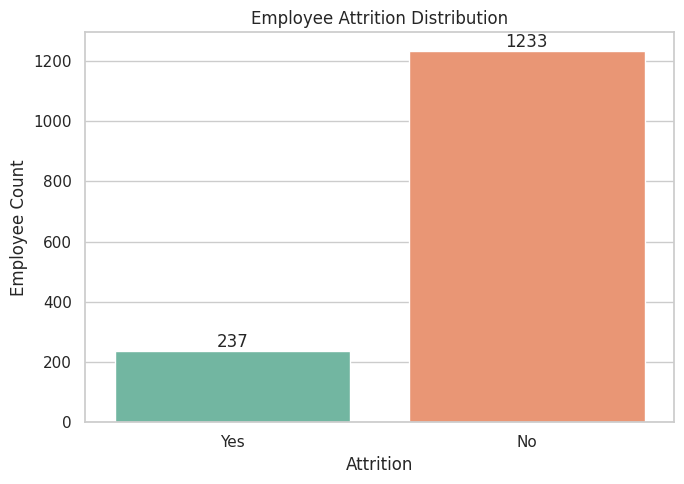

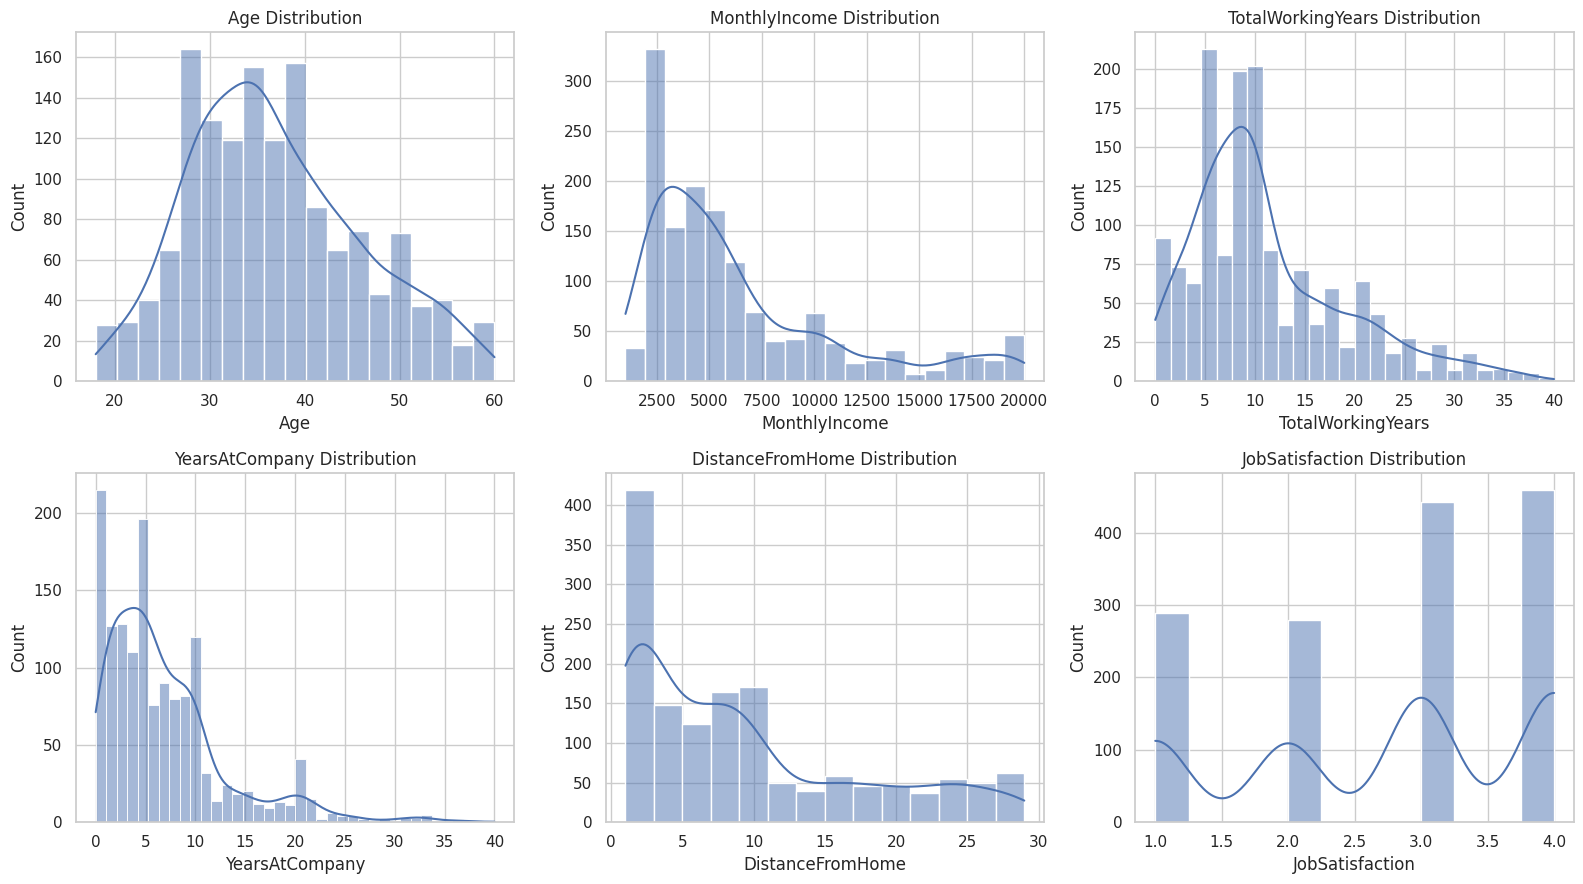

In [5]:
plt.figure(figsize=(7, 5))
labels = df["Attrition"].map({0: "No", 1: "Yes"})
ax = sns.countplot(x=labels, hue=labels, palette="Set2", legend=False)
ax.set_title("Employee Attrition Distribution")
ax.set_xlabel("Attrition")
ax.set_ylabel("Employee Count")
for patch in ax.patches:
    height = int(patch.get_height())
    ax.annotate(f"{height}", (patch.get_x() + patch.get_width() / 2.0, height), ha="center", va="bottom")
plt.tight_layout()
plt.show()

candidate_columns = [
    column for column in ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "DistanceFromHome", "JobSatisfaction"]
    if column in df.columns
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for index, column in enumerate(candidate_columns):
    sns.histplot(df[column], kde=True, ax=axes[index], color="#4C72B0")
    axes[index].set_title(f"{column} Distribution")
for index in range(len(candidate_columns), len(axes)):
    axes[index].axis("off")
fig.tight_layout()
plt.show()

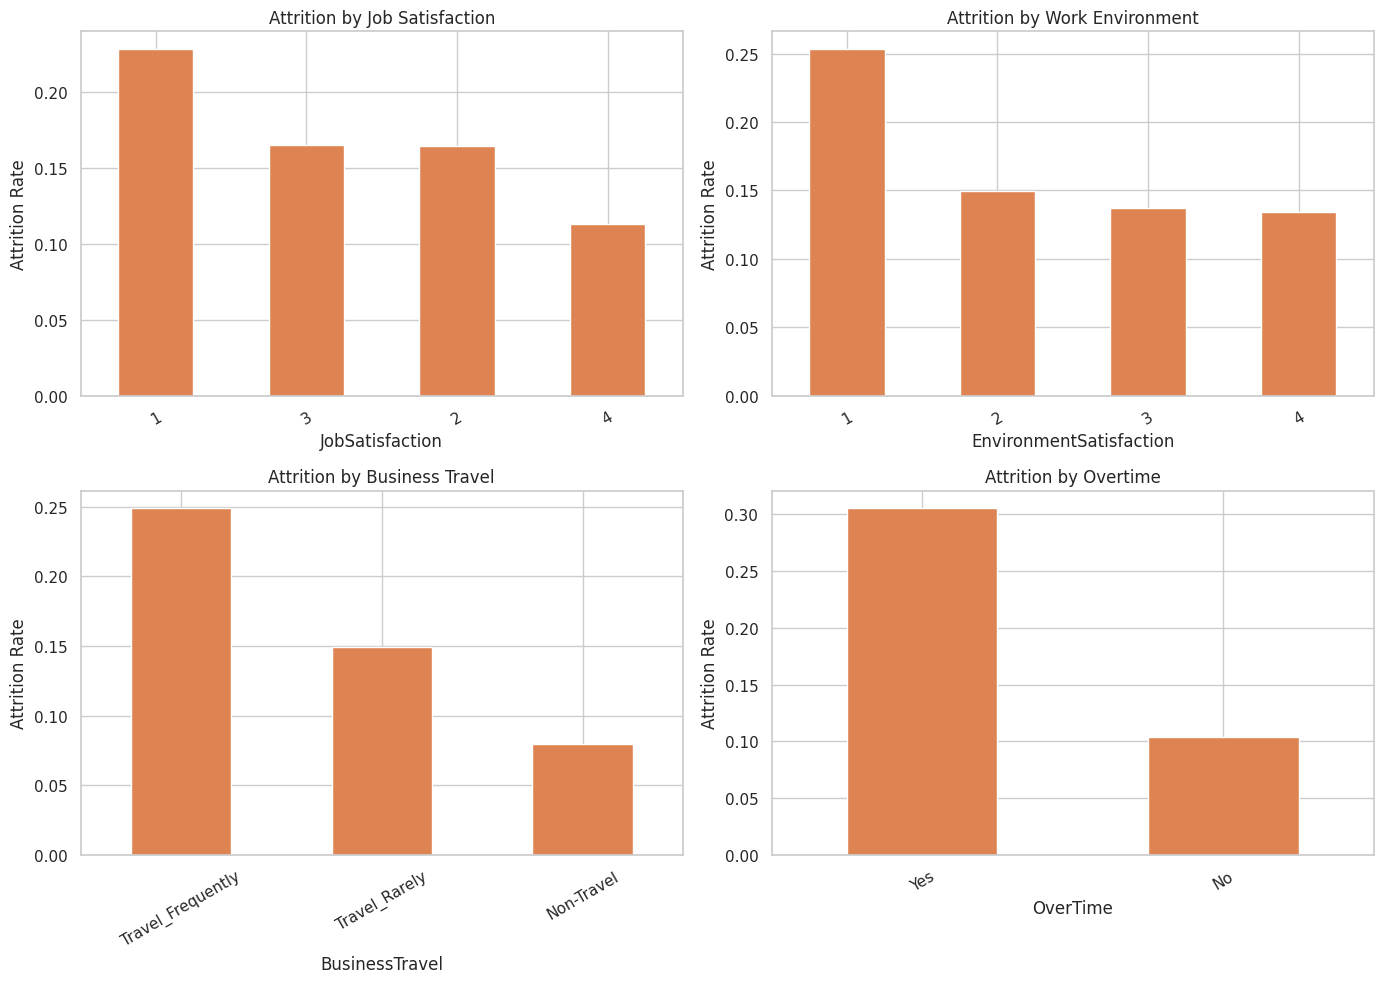

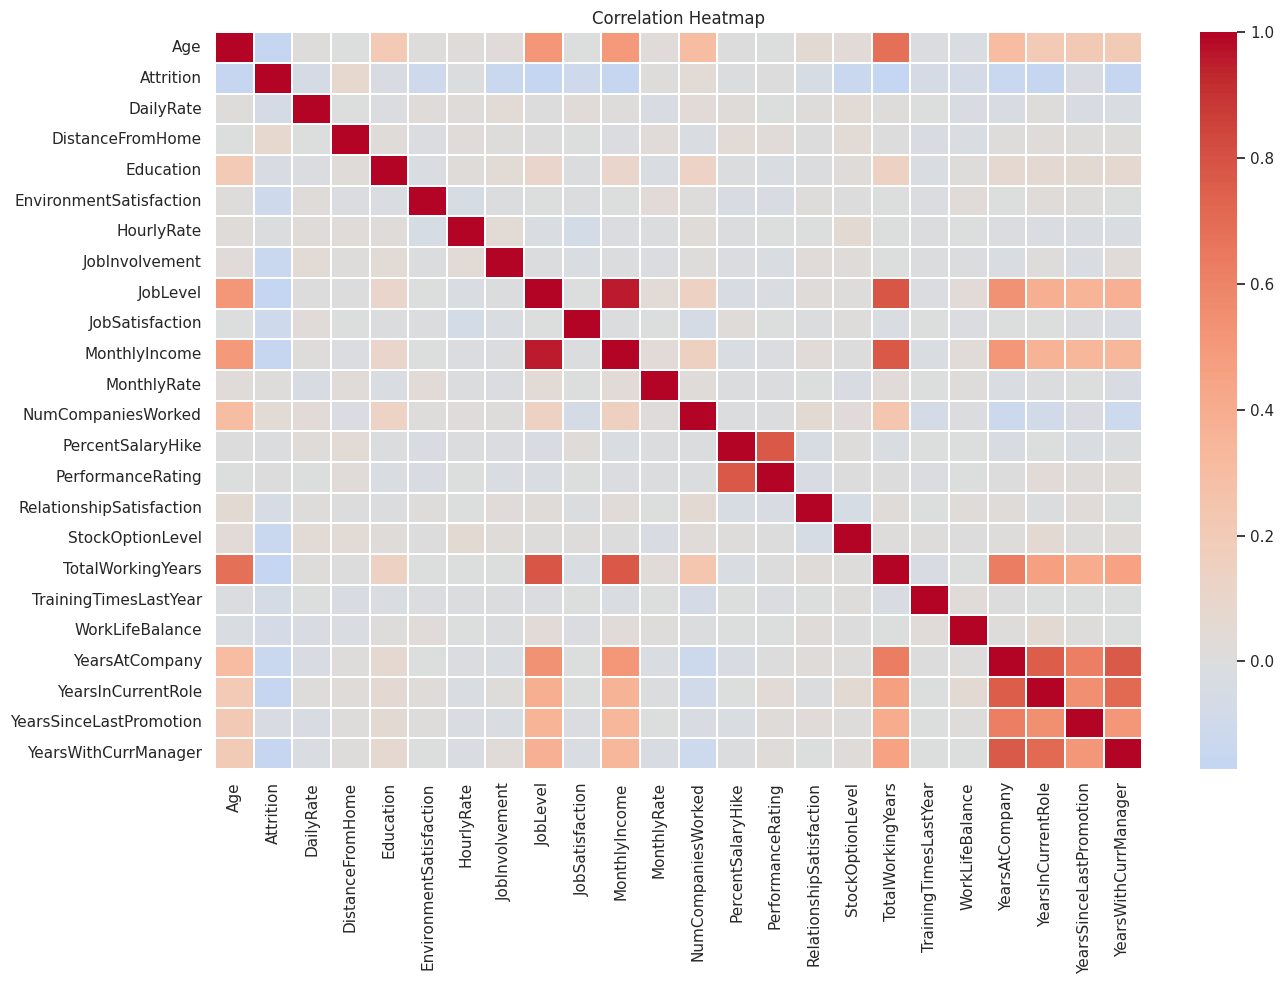

In [6]:
relationship_specs = [
    ("JobSatisfaction", "Attrition by Job Satisfaction"),
    ("EnvironmentSatisfaction", "Attrition by Work Environment"),
    ("BusinessTravel", "Attrition by Business Travel"),
    ("OverTime", "Attrition by Overtime")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (feature, title) in zip(axes, relationship_specs):
    if feature in df.columns:
        normalized = (
            pd.crosstab(df[feature], df["Attrition"], normalize="index")
            .reindex(columns=[0, 1], fill_value=0)
            .rename(columns={0: "No", 1: "Yes"})
        )
        normalized["Yes"].sort_values(ascending=False).plot(kind="bar", color="#DD8452", ax=ax)
        ax.set_title(title)
        ax.set_ylabel("Attrition Rate")
        ax.tick_params(axis="x", rotation=30)
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(numeric_only=True), cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing and model training

In [7]:
X = df.drop(columns="Attrition")
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

def build_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=4, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
fitted_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", build_preprocessor()), ("model", model)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
    })
    fitted_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(output_dir / "model_comparison_metrics.csv", index=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.751701,0.348837,0.638298,0.451128
1,Random Forest,0.843537,0.516129,0.340426,0.410256
2,Decision Tree,0.727891,0.310345,0.574468,0.402985


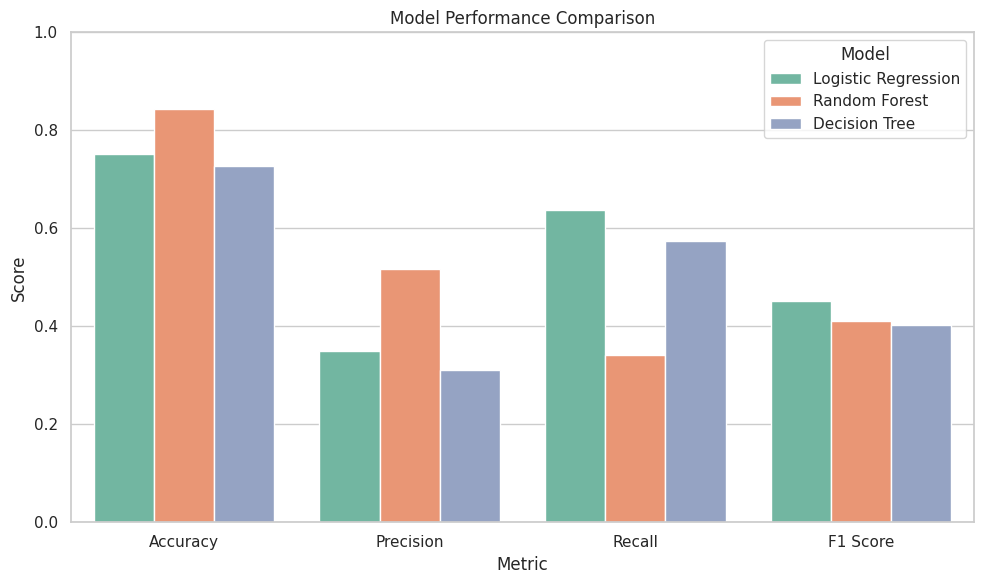


Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294



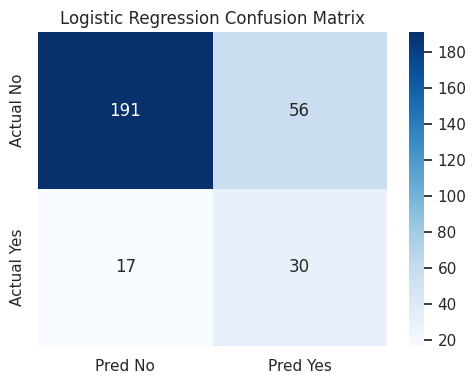


Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.76      0.82       247
           1       0.31      0.57      0.40        47

    accuracy                           0.73       294
   macro avg       0.61      0.67      0.61       294
weighted avg       0.81      0.73      0.76       294



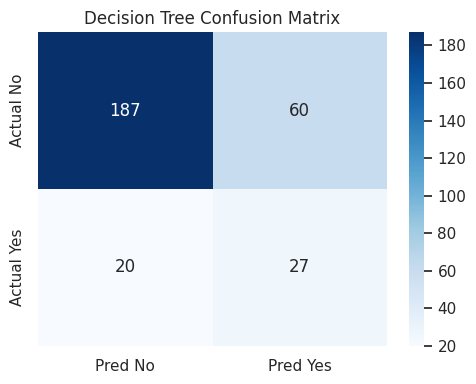


Random Forest
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.52      0.34      0.41        47

    accuracy                           0.84       294
   macro avg       0.70      0.64      0.66       294
weighted avg       0.82      0.84      0.83       294



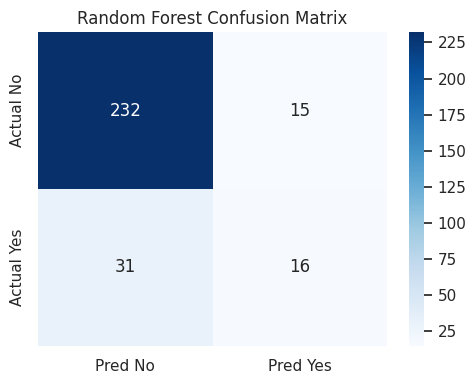

In [8]:
plt.figure(figsize=(10, 6))
plot_df = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1 Score"], var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Set2")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

for model_name, pipeline in fitted_models.items():
    predictions = pipeline.predict(X_test)
    print(f"\n{model_name}")
    print(classification_report(y_test, predictions, zero_division=0))
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred No", "Pred Yes"], yticklabels=["Actual No", "Actual Yes"])
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

## Top factors influencing attrition

,feature,importance
42,cat__JobRole_Research Director,1.465683
39,cat__JobRole_Laboratory Technician,1.194333
45,cat__JobRole_Sales Representative,1.120617
23,cat__BusinessTravel_Non-Travel,0.993885
49,cat__OverTime_No,0.892809
33,cat__EducationField_Other,0.798108
24,cat__BusinessTravel_Travel_Frequently,0.787566
50,cat__OverTime_Yes,0.761522
29,cat__EducationField_Human Resources,0.721129
37,cat__JobRole_Healthcare Representative,0.647202


,feature,importance
9,num__MonthlyIncome,0.080392
0,num__Age,0.065141
16,num__TotalWorkingYears,0.060629
19,num__YearsAtCompany,0.050410
1,num__DailyRate,0.045548
22,num__YearsWithCurrManager,0.041990
49,cat__OverTime_No,0.039383
2,num__DistanceFromHome,0.039356
50,cat__OverTime_Yes,0.038923
11,num__NumCompaniesWorked,0.037168


,feature,importance_mean,importance_std
50,cat__OverTime_Yes,0.025170,0.008405
49,cat__OverTime_No,0.020181,0.007500
15,num__StockOptionLevel,0.012018,0.007438
2,num__DistanceFromHome,0.008617,0.005673
48,cat__MaritalStatus_Single,0.008163,0.008405
4,num__EnvironmentSatisfaction,0.005215,0.005250
8,num__JobSatisfaction,0.004762,0.003888
14,num__RelationshipSatisfaction,0.004535,0.003207
5,num__HourlyRate,0.004308,0.005619
7,num__JobLevel,0.004082,0.005442


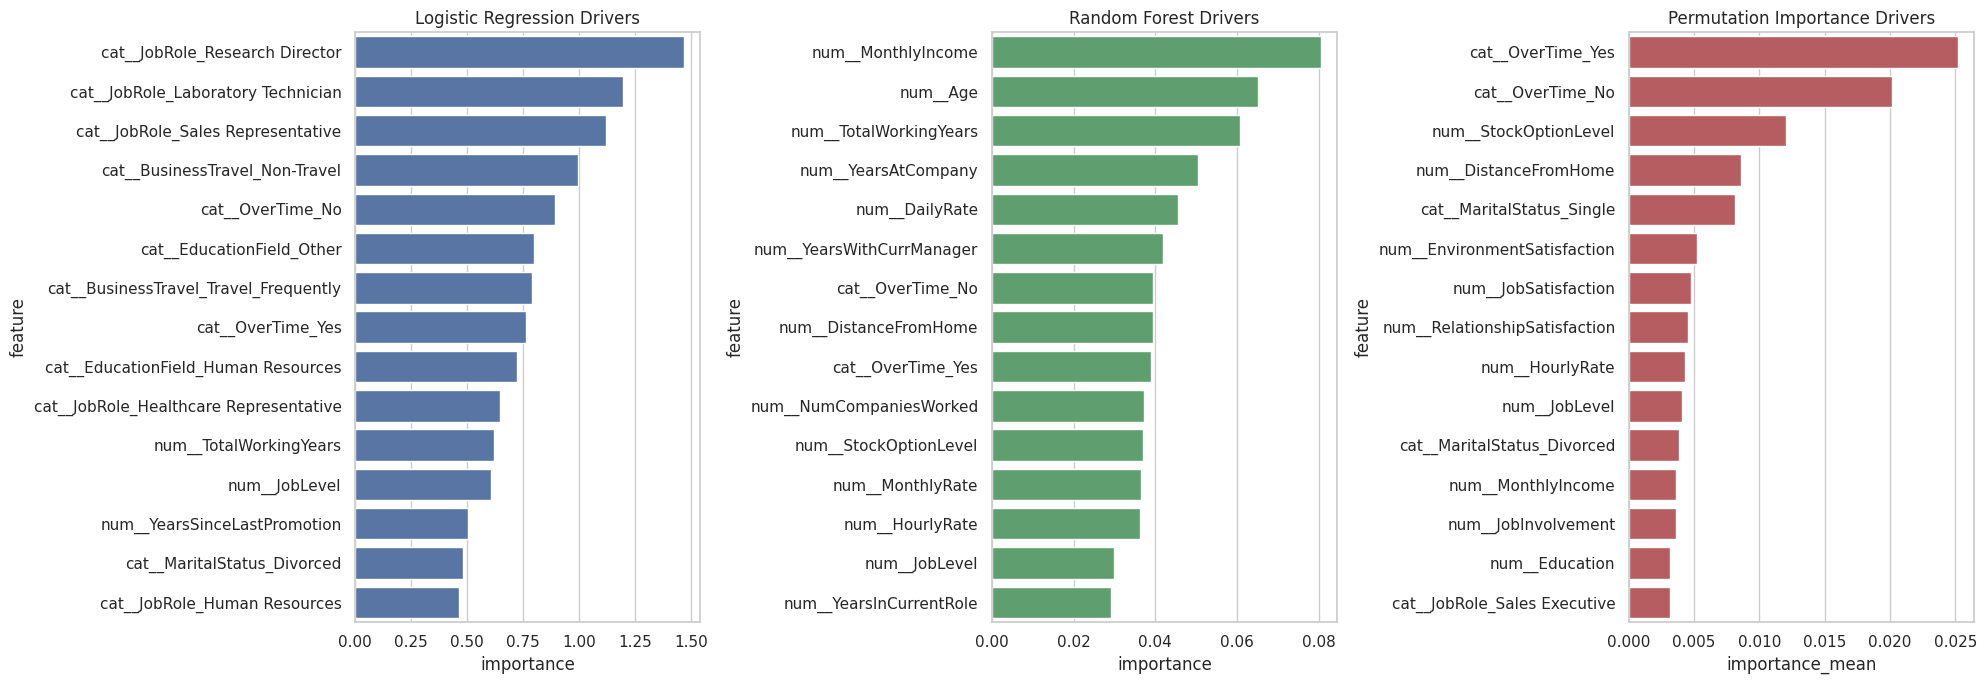

In [9]:
lr_pipeline = fitted_models["Logistic Regression"]
rf_pipeline = fitted_models["Random Forest"]

lr_feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
lr_coefficients = np.abs(lr_pipeline.named_steps["model"].coef_[0])
lr_importance = pd.DataFrame({"feature": lr_feature_names, "importance": lr_coefficients}).sort_values(by="importance", ascending=False).head(15)
display(lr_importance)

rf_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_pipeline.named_steps["model"].feature_importances_
rf_importance = pd.DataFrame({"feature": rf_feature_names, "importance": rf_importances}).sort_values(by="importance", ascending=False).head(15)
display(rf_importance)

transformed_X_test = rf_pipeline.named_steps["preprocessor"].transform(X_test)
permutation = permutation_importance(rf_pipeline.named_steps["model"], transformed_X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1)
permutation_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values(by="importance_mean", ascending=False).head(15)
display(permutation_df)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.barplot(data=lr_importance, x="importance", y="feature", color="#4C72B0", ax=axes[0])
axes[0].set_title("Logistic Regression Drivers")
sns.barplot(data=rf_importance, x="importance", y="feature", color="#55A868", ax=axes[1])
axes[1].set_title("Random Forest Drivers")
sns.barplot(data=permutation_df, x="importance_mean", y="feature", color="#C44E52", ax=axes[2])
axes[2].set_title("Permutation Importance Drivers")
plt.tight_layout()
plt.show()

In [10]:
print("Most important attrition factors usually come from job satisfaction, overtime, income, tenure, travel, and work environment variables.")
print("Use the importance tables above as your final ranked factors for this run.")

Most important attrition factors usually come from job satisfaction, overtime, income, tenure, travel, and work environment variables.
Use the importance tables above as your final ranked factors for this run.
